In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman
from itertools import islice

In [3]:
# Load the Zachary's Karate Club graph
G = nx.karate_club_graph()

In [4]:
# Compute centrality measures and diameter
# Nodes with high centrality are often central players in the network and might play key roles in their communities.
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)
clustering_coefficient = nx.clustering(G)
diameter = nx.diameter(G)

print("Degree centrality:     ", degree_centrality)
print("Closeness centrality:  ", closeness_centrality)
print("Betweenness centrality:", betweenness_centrality)
print("Eigenvector centrality:", eigenvector_centrality)
print("Clustering coefficient:", clustering_coefficient)
print("Diameter of the graph: ", diameter)

Degree centrality:      {0: 0.48484848484848486, 1: 0.2727272727272727, 2: 0.30303030303030304, 3: 0.18181818181818182, 4: 0.09090909090909091, 5: 0.12121212121212122, 6: 0.12121212121212122, 7: 0.12121212121212122, 8: 0.15151515151515152, 9: 0.06060606060606061, 10: 0.09090909090909091, 11: 0.030303030303030304, 12: 0.06060606060606061, 13: 0.15151515151515152, 14: 0.06060606060606061, 15: 0.06060606060606061, 16: 0.06060606060606061, 17: 0.06060606060606061, 18: 0.06060606060606061, 19: 0.09090909090909091, 20: 0.06060606060606061, 21: 0.06060606060606061, 22: 0.06060606060606061, 23: 0.15151515151515152, 24: 0.09090909090909091, 25: 0.09090909090909091, 26: 0.06060606060606061, 27: 0.12121212121212122, 28: 0.09090909090909091, 29: 0.12121212121212122, 30: 0.12121212121212122, 31: 0.18181818181818182, 32: 0.36363636363636365, 33: 0.5151515151515151}
Closeness centrality:   {0: 0.5689655172413793, 1: 0.4852941176470588, 2: 0.559322033898305, 3: 0.4647887323943662, 4: 0.379310344827586

In [5]:
# Community detection using the Girvan-Newman algorithm
communities = girvan_newman(G)
top_level_communities = next(islice(communities, 1))  # Get the first division of communities
community_list = [list(community) for community in top_level_communities]
print("\nCommunities detected:  ", community_list)


Communities detected:   [[0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]]


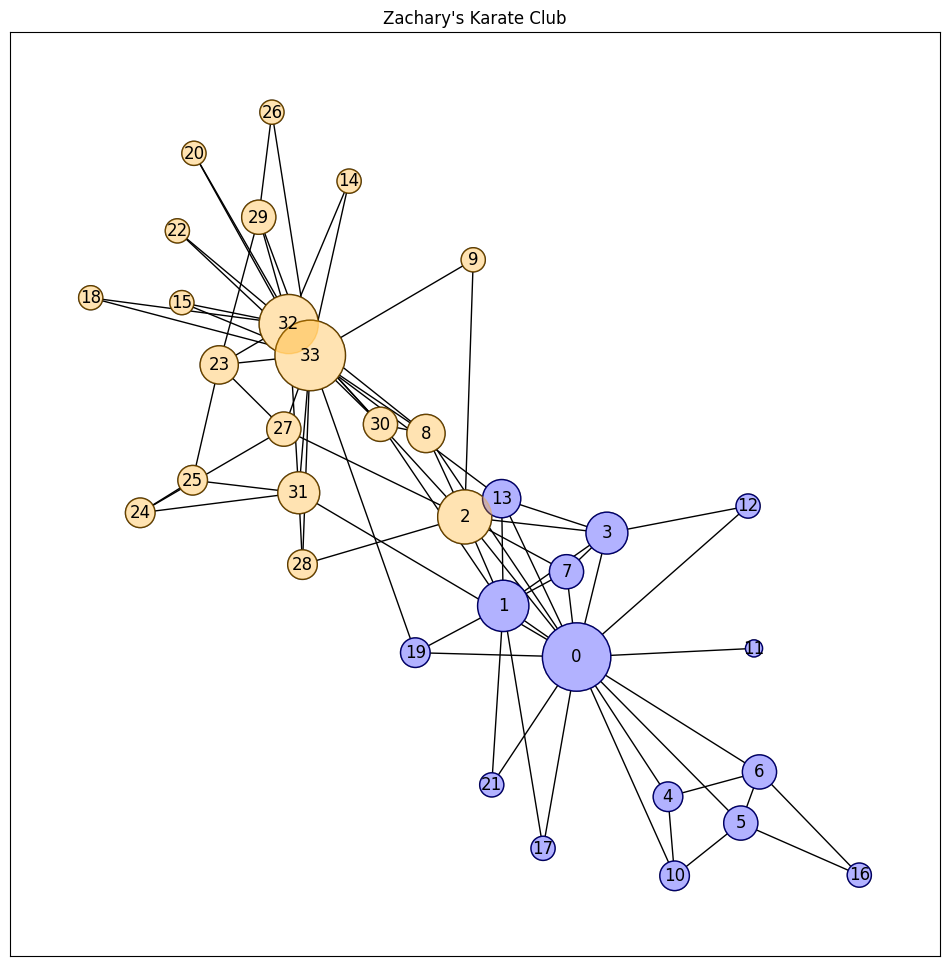

In [6]:
# Draw the graph and highlight important features
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G)
# Node size based on degree centrality
node_size = [v * 5000 for v in degree_centrality.values()]
# Draw the nodes
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="white", edgecolors="black")
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)

# Highlight the communities
colors = ['blue', 'orange', 'red', 'purple', 'yellow', 'pink', 'grey', 'brown']
for i, community in enumerate(community_list):
    nx.draw_networkx_nodes(G, pos, nodelist=community, node_color=colors[i],
                           node_size=[node_size[i] for i in community], alpha=0.3)

plt.title("Zachary's Karate Club")
plt.show()

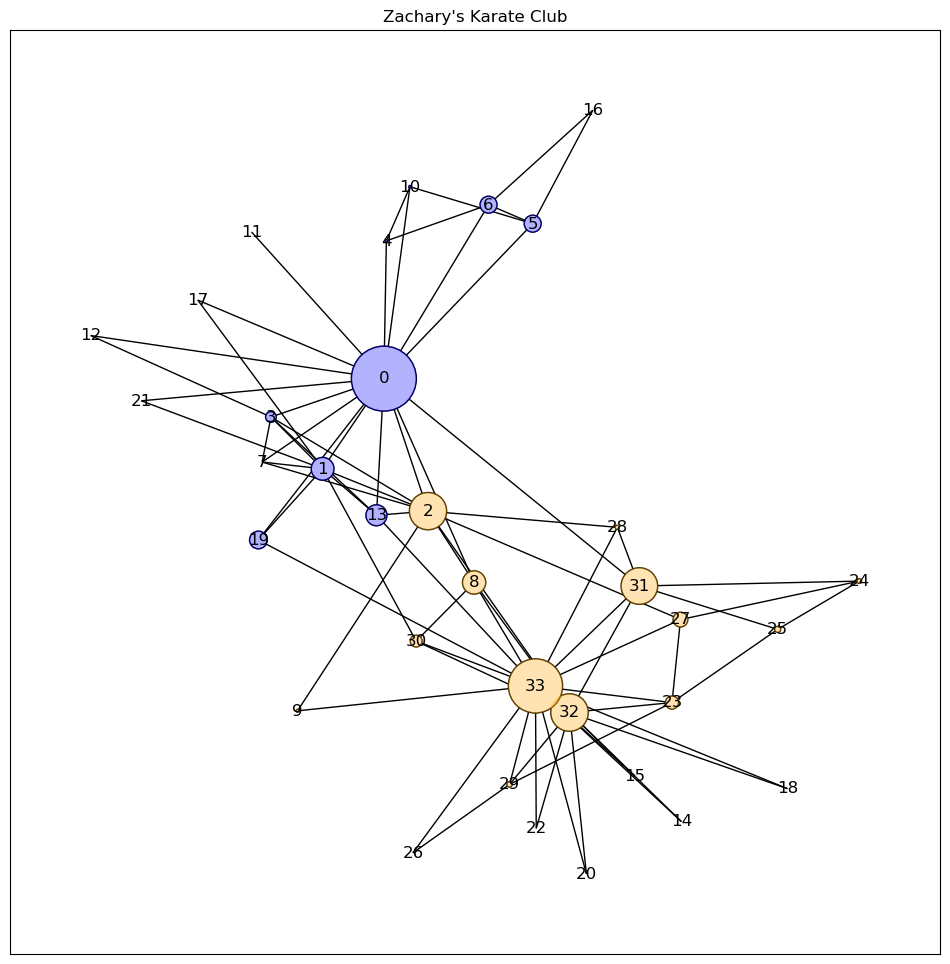

In [11]:
# Draw the graph and highlight important features
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G)
# Node size based on degree centrality
node_size = [v * 5000 for v in betweenness_centrality.values()]
# Draw the nodes
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="white", edgecolors="black")
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)

# Highlight the communities
colors = ['blue', 'orange', 'red', 'purple', 'yellow', 'pink', 'grey', 'brown']
for i, community in enumerate(community_list):
    nx.draw_networkx_nodes(G, pos, nodelist=community, node_color=colors[i],
                           node_size=[node_size[i] for i in community], alpha=0.3)

plt.title("Zachary's Karate Club")
plt.show()

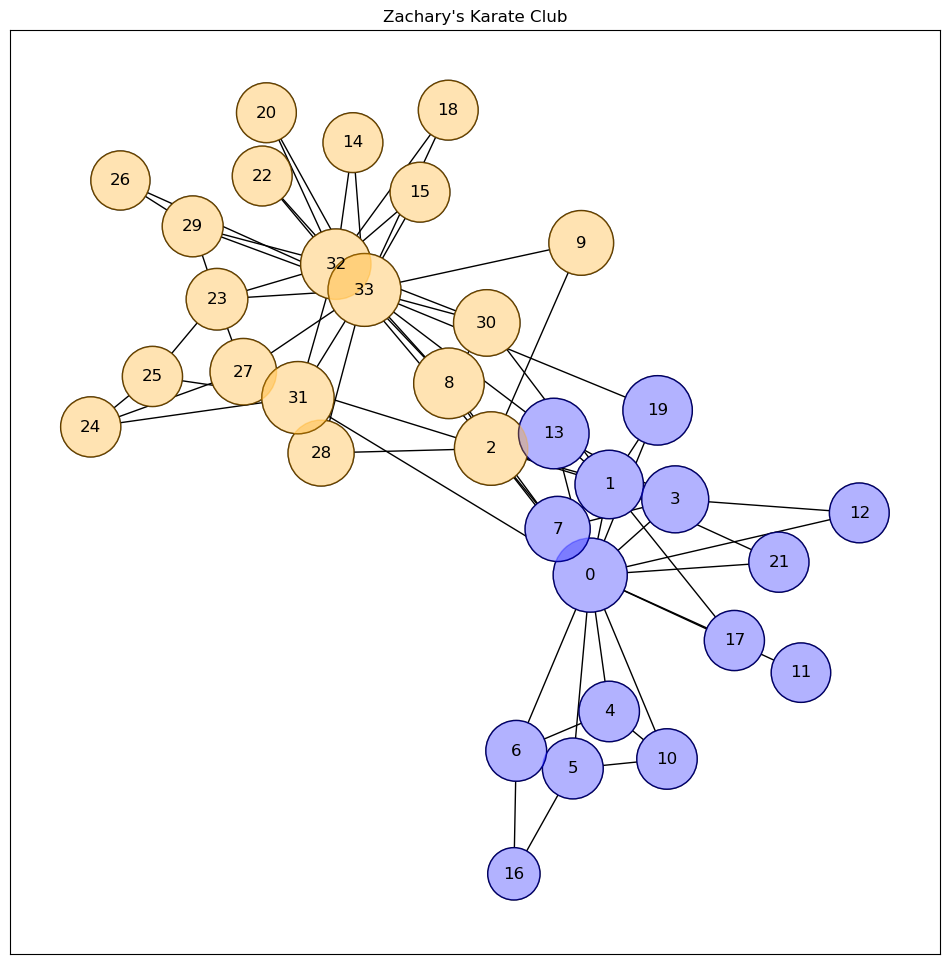

In [12]:
# Draw the graph and highlight important features
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G)
# Node size based on degree centrality
node_size = [v * 5000 for v in closeness_centrality.values()]
# Draw the nodes
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="white", edgecolors="black")
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)

# Highlight the communities
colors = ['blue', 'orange', 'red', 'purple', 'yellow', 'pink', 'grey', 'brown']
for i, community in enumerate(community_list):
    nx.draw_networkx_nodes(G, pos, nodelist=community, node_color=colors[i],
                           node_size=[node_size[i] for i in community], alpha=0.3)

plt.title("Zachary's Karate Club")
plt.show()

In [14]:
# Top 3 important people by centrality measures
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:3]
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:3]
top_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:3]
top_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:3]

print("\nTop 3 nodes by degree centrality:     ", top_degree)
print("Top 3 nodes by betweenness centrality:", top_betweenness)
print("Top 3 nodes by closeness centrality:  ", top_closeness)
print("Top 3 nodes by eigenvector centrality:", top_eigenvector)


Top 3 nodes by degree centrality:      [(33, 0.5151515151515151), (0, 0.48484848484848486), (32, 0.36363636363636365)]
Top 3 nodes by betweenness centrality: [(0, 0.43763528138528146), (33, 0.30407497594997596), (32, 0.145247113997114)]
Top 3 nodes by closeness centrality:   [(0, 0.5689655172413793), (2, 0.559322033898305), (33, 0.55)]
Top 3 nodes by eigenvector centrality: [(33, 0.37337121301323506), (0, 0.35548349418519426), (2, 0.3171893899684447)]
